# 기둥 표식(띠) 기반 침수심 측정 — Jupyter 버전**핵심 아이디어**: 물을 직접 인식하지 않습니다. 신호등 기둥에 붙은 **일정 간격 표식(흰띠)** 을 검출하고,"**몇 번째 띠까지 보이는가**"로 수위를 역산합니다.**표식 규격 (도로면 기준 누적 높이)**| 구간 | 높이 | 도로면 기준 누적 ||---|---|---|| 연석 (도로 → 보도) | 14 cm | 0 → 14 || 삼각부 (보도면 → 띠 시작) | 25 cm | 14 → 39 || 흰띠 1 | 5 cm | 39 → 44 || 간격 1 | 5 cm | 44 → 49 || 흰띠 2 | 5 cm | 49 → 54 || ... | 10 cm 주기 | ... |**파이프라인**1. `ROI 지정` — 기둥 하단(보도면 접점)과 표식 상단, 2점만 지정 (1회)2. `보정(calibrate)` — 마른 날 영상에서 전체 띠를 검출해 **픽셀 행 ↔ 실제 cm** 모델을 fit3. `측정(measure)` — 침수 영상에서 **가장 낮게 보이는 띠**를 찾아 수위 산출 (+ 경계 정밀화)4. `분류(classify)` — 0~4단계 침수 등급 + 시각화 + CSV기존 `flood_depth_cctv.py`처럼 매 프레임 점을 찍지 않습니다. ROI 2점만 1회 지정하면 이후는 전자동입니다.

## 0. 환경 준비

In [1]:
# 필요 패키지: opencv-python, numpy, matplotlib
# (설치 안 되어 있으면 아래 주석 해제 후 1회 실행)
# !pip install opencv-python numpy matplotlib

import json
import math
from dataclasses import dataclass, asdict, field
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (11, 4)

# 그래프 한글 깨짐 방지 (Windows: 맑은 고딕)
for _f in ["Malgun Gothic", "NanumGothic", "AppleGothic"]:
    try:
        from matplotlib import font_manager
        if any(_f == f.name for f in font_manager.fontManager.ttflist):
            plt.rcParams["font.family"] = _f
            plt.rcParams["axes.unicode_minus"] = False
            break
    except Exception:
        pass

print("OpenCV:", cv2.__version__)
print("NumPy :", np.__version__)

OpenCV: 4.10.0
NumPy : 2.4.6


In [2]:
# ── 한글/공백 포함 Windows 경로 안전 입출력 ──────────────────────────────
def imread_kr(path):
    """한글 경로도 읽을 수 있는 cv2.imread 대체."""
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"파일이 없습니다: {p}")
    img = cv2.imdecode(np.fromfile(str(p), dtype=np.uint8), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"이미지 디코딩 실패: {p}")
    return img


def imwrite_kr(path, img):
    """한글 경로도 저장 가능한 cv2.imwrite 대체."""
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)
    ext = p.suffix.lower() if p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp"} else ".png"
    ok, buf = cv2.imencode(ext, img)
    if not ok:
        raise RuntimeError(f"인코딩 실패: {p}")
    buf.tofile(str(p))
    return p


def show(img, title="", figsize=(11, 7)):
    """Jupyter 인라인 표시(BGR→RGB)."""
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img, cmap=None if img.ndim == 3 else "gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


def save_json(path, data):
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)
    with open(p, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    return p


def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

print("유틸 로드 완료")

유틸 로드 완료


## 1. 표식 규격 정의여기 숫자만 바꾸면 다른 현장/다른 표식에도 그대로 재사용됩니다.`n_stripes` 는 기둥에 실제로 붙인 흰띠 개수로 맞춰 주세요.

In [3]:
@dataclass
class MarkerSpec:
    curb_height_cm: float = 14.0       # 연석 높이 (도로면 → 보도면)
    triangle_height_cm: float = 25.0   # 삼각부 (보도면 → 첫 흰띠 하단)
    stripe_cm: float = 5.0             # 흰띠 1개 높이
    gap_cm: float = 5.0                # 흰띠 사이 간격
    n_stripes: int = 8                 # 흰띠 총 개수

    @property
    def period_cm(self):
        return self.stripe_cm + self.gap_cm

    @property
    def base_cm(self):
        """도로면 기준, 첫 흰띠 하단 높이."""
        return self.curb_height_cm + self.triangle_height_cm

    def stripe_bounds_cm(self, i):
        """i번째(1-base) 흰띠의 (하단, 상단) 높이 — 도로면 기준 cm."""
        lo = self.base_cm + (i - 1) * self.period_cm
        return lo, lo + self.stripe_cm

    def stripe_center_cm(self, i):
        lo, hi = self.stripe_bounds_cm(i)
        return (lo + hi) / 2.0

    def table(self):
        rows = [("연석", 0.0, self.curb_height_cm),
                ("삼각부", self.curb_height_cm, self.base_cm)]
        for i in range(1, self.n_stripes + 1):
            lo, hi = self.stripe_bounds_cm(i)
            rows.append((f"흰띠 {i}", lo, hi))
            if i < self.n_stripes:
                rows.append((f"간격 {i}", hi, hi + self.gap_cm))
        return rows

    @property
    def top_cm(self):
        """표식 최상단(마지막 흰띠 상단) 높이 — 도로면 기준."""
        return self.stripe_bounds_cm(self.n_stripes)[1]


SPEC = MarkerSpec()

print(f"도로면 기준 첫 띠 하단 : {SPEC.base_cm:.0f} cm")
print(f"도로면 기준 표식 최상단 : {SPEC.top_cm:.0f} cm")
print(f"띠 주기                 : {SPEC.period_cm:.0f} cm\n")
print(f"{'구간':<10}{'하단(cm)':>10}{'상단(cm)':>10}")
print("-" * 30)
for name, lo, hi in SPEC.table():
    print(f"{name:<10}{lo:>10.0f}{hi:>10.0f}")

도로면 기준 첫 띠 하단 : 39 cm
도로면 기준 표식 최상단 : 114 cm
띠 주기                 : 10 cm

구간            하단(cm)    상단(cm)
------------------------------
연석                 0        14
삼각부               14        39
흰띠 1              39        44
간격 1              44        49
흰띠 2              49        54
간격 2              54        59
흰띠 3              59        64
간격 3              64        69
흰띠 4              69        74
간격 4              74        79
흰띠 5              79        84
간격 5              84        89
흰띠 6              89        94
간격 6              94        99
흰띠 7              99       104
간격 7             104       109
흰띠 8             109       114


## 2. 침수 등급 기준프로젝트(MindOne) 기준 값으로 교체해서 쓰시면 됩니다. 아래 임계값은 **가정치**입니다.

In [4]:
# [가정] 도로면 기준 침수심(cm) 임계값 — 프로젝트 확정 기준으로 교체하세요.
LEVEL_THRESHOLDS_CM = [5.0, 15.0, 25.0, 40.0]
LEVEL_NAMES = ["0단계 (정상)", "1단계 (관심)", "2단계 (주의)", "3단계 (경계)", "4단계 (심각)"]
LEVEL_COLORS_BGR = [(120, 200, 120), (80, 220, 240), (60, 165, 255), (60, 90, 245), (140, 40, 200)]


def classify_level(depth_cm):
    """도로면 기준 침수심(cm) → 0~4 등급."""
    if depth_cm is None:
        return None
    level = 0
    for t in LEVEL_THRESHOLDS_CM:
        if depth_cm >= t:
            level += 1
    return level


for d in [0, 8, 20, 33, 55]:
    lv = classify_level(d)
    print(f"{d:>3} cm → {LEVEL_NAMES[lv]}")

  0 cm → 0단계 (정상)
  8 cm → 1단계 (관심)
 20 cm → 2단계 (주의)
 33 cm → 3단계 (경계)
 55 cm → 4단계 (심각)


## 3. ROI(기둥 축) 지정 — 1회만기둥을 따라 **2점**만 지정합니다.- **P_bottom** : 기둥이 보도면과 만나는 접점 (도로면 기준 = 연석 높이 14 cm)- **P_top** : 표식 최상단(마지막 흰띠 위쪽 끝)`half_width_px` 는 기둥 좌우로 몇 px을 샘플링할지 (기둥 반폭 정도).**두 가지 방법 중 편한 쪽을 쓰세요.**- (A) `pick_roi_by_click()` — cv2 창이 뜨고 클릭 (로컬 Jupyter에서 동작)- (B) `make_roi(...)` — 좌표를 숫자로 직접 입력 (원격/헤드리스 환경)> ⚠️ **보정 이미지는 반드시 표식이 붙어 있는 캡처**여야 합니다. 표식 없는 원본으로는 띠가 없어 보정이 불가능합니다.> `img=` 인자를 넘기면 좌표가 화면 밖인지 자동으로 검사하고, 이미지 크기까지 기록해> 나중에 해상도가 다른 프레임이 들어와도 자동으로 맞춰 줍니다.> 기둥 위치를 모르겠으면 `probe_column(img, x, y0, y1)` 으로 세로 밝기 그래프를 먼저 보세요.

In [5]:
def make_roi(p_bottom, p_top, half_width_px, spec=SPEC, img=None,
             bottom_cm=None, top_cm=None, target_px_per_cm=4.0):
    """ROI 딕셔너리 생성 (+ 좌표 유효성 검사 + 밴드 해상도 고정).

    p_bottom / p_top : (x, y) 원본 이미지 좌표
    img              : 주면 좌표가 이미지 범위 안인지 검사합니다. (권장)
    target_px_per_cm : 띠 검출용 최소 해상도. CCTV에서 띠가 5px밖에 안 되는 경우가
                       흔하므로 밴드를 이 값 이상으로 업샘플링해 검출 안정성을 확보합니다.
    """
    pb = np.array(p_bottom, np.float64)
    pt = np.array(p_top, np.float64)

    if img is not None:
        h, w = img.shape[:2]
        for name, p in [("p_bottom", pb), ("p_top", pt)]:
            if not (0 <= p[0] < w and 0 <= p[1] < h):
                raise ValueError(
                    f"{name}={tuple(p)} 가 이미지 범위를 벗어났습니다. "
                    f"이 이미지 크기는 (가로 {w}, 세로 {h}) 입니다. "
                    f"좌표를 다시 확인하세요.")
        if pt[1] >= pb[1]:
            raise ValueError("p_top 이 p_bottom 보다 아래에 있습니다. 순서를 바꿔 주세요.")

    L = float(np.linalg.norm(pt - pb))
    if L < 10:
        raise ValueError(f"ROI 두 점 거리가 {L:.1f}px 뿐입니다. 기둥 위/아래를 넓게 잡아 주세요.")

    b_cm = float(spec.curb_height_cm if bottom_cm is None else bottom_cm)
    t_cm = float(spec.top_cm if top_cm is None else top_cm)
    span_cm = t_cm - b_cm
    scale = max(1.0, target_px_per_cm * span_cm / L)     # 띠가 얇으면 업샘플링

    roi = {
        "p_bottom": [float(pb[0]), float(pb[1])],
        "p_top": [float(pt[0]), float(pt[1])],
        "half_width_px": float(half_width_px),
        "bottom_cm": b_cm, "top_cm": t_cm,
        "band_height": int(round(L * scale)),
        "band_width": int(max(6, round(half_width_px * 2 * scale))),
        "scale": float(scale),
        "image_size": None if img is None else [int(img.shape[1]), int(img.shape[0])],
    }
    print(f"ROI 생성: 기둥 길이 {L:.1f}px / 실제 {span_cm:.0f}cm "
          f"→ 원본 {L / span_cm:.2f} px/cm, 업샘플 x{scale:.1f} "
          f"→ 밴드 {roi['band_height']}x{roi['band_width']}px "
          f"({roi['band_height'] / span_cm:.1f} px/cm, 흰띠 {roi['band_height'] / span_cm * spec.stripe_cm:.1f}px)")
    return roi


def probe_column(img, x, y0, y1, width=16):
    """기둥이 어디 있는지 모를 때: 세로 밝기 프로파일을 찍어 띠 위치를 눈으로 찾습니다."""
    g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
    h, w = g.shape
    x0, x1 = int(max(0, x - width // 2)), int(min(w, x + width // 2))
    y0, y1 = int(max(0, y0)), int(min(h, y1))
    prof = np.median(g[y0:y1, x0:x1], axis=1)
    plt.figure(figsize=(11, 3.4))
    plt.plot(np.arange(y0, y1), prof, lw=1.2)
    plt.xlabel("y (원본 이미지 좌표)"); plt.ylabel("밝기"); plt.grid(alpha=.3)
    plt.title(f"x={x}±{width // 2} 세로 밝기 — 톱니처럼 반복되는 구간이 띠입니다")
    plt.tight_layout(); plt.show()
    return prof


def pick_roi_by_click(img, half_width_px=14, spec=SPEC, max_width=1400, max_height=900):
    """cv2 창에서 기둥 하단 → 표식 상단 순으로 2점 클릭. U=취소, Enter/Q=확정, Esc=중단."""
    h, w = img.shape[:2]
    s = min(max_width / w, max_height / h, 1.0)
    disp = cv2.resize(img, (round(w * s), round(h * s)), interpolation=cv2.INTER_AREA) if s < 1 else img.copy()
    pts = []
    labels = ["1) Pole-sidewalk contact (bottom)", "2) Top edge of the highest stripe"]

    def on_mouse(event, x, y, flags, userdata):
        if event == cv2.EVENT_LBUTTONDOWN and len(pts) < 2:
            pts.append((x / s, y / s))

    win = "Pick ROI (2 points)"
    cv2.namedWindow(win, cv2.WINDOW_AUTOSIZE)
    cv2.setMouseCallback(win, on_mouse)
    try:
        while True:
            canvas = disp.copy()
            for i, (px, py) in enumerate(pts):
                cv2.circle(canvas, (int(px * s), int(py * s)), 5, (0, 0, 255), -1)
                cv2.putText(canvas, str(i + 1), (int(px * s) + 8, int(py * s) - 6),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2, cv2.LINE_AA)
            if len(pts) == 2:
                cv2.line(canvas, tuple(np.int32(np.array(pts[0]) * s)),
                         tuple(np.int32(np.array(pts[1]) * s)), (0, 255, 255), 2)
            msg = labels[len(pts)] if len(pts) < 2 else "Enter/Q: confirm | U: undo"
            cv2.rectangle(canvas, (0, 0), (canvas.shape[1], 40), (0, 0, 0), -1)
            cv2.putText(canvas, msg, (10, 27), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
            cv2.imshow(win, canvas)
            k = cv2.waitKey(20) & 0xFF
            if k in (ord("u"), ord("U")) and pts:
                pts.pop()
            elif k in (13, ord("q"), ord("Q")) and len(pts) == 2:
                break
            elif k == 27:
                raise KeyboardInterrupt("ROI 지정 취소")
    finally:
        cv2.destroyAllWindows()
        for _ in range(4):
            cv2.waitKey(1)
    return make_roi(pts[0], pts[1], half_width_px, spec, img=img)


def preview_roi(img, roi, spec=SPEC):
    """ROI 사각형을 원본 위에 그려 확인."""
    pb = np.array(roi["p_bottom"], np.float32)
    pt = np.array(roi["p_top"], np.float32)
    axis = pt - pb
    L = float(np.linalg.norm(axis))
    u = axis / (L + 1e-9)
    n = np.array([-u[1], u[0]], np.float32) * roi["half_width_px"]
    corners = np.int32([pt - n, pt + n, pb + n, pb - n])
    vis = img.copy()
    cv2.polylines(vis, [corners], True, (0, 255, 255), 2, cv2.LINE_AA)
    cv2.circle(vis, tuple(np.int32(pb)), 5, (0, 0, 255), -1)
    cv2.circle(vis, tuple(np.int32(pt)), 5, (255, 0, 0), -1)
    return vis

print("ROI 함수 준비 완료")

ROI 함수 준비 완료


이미지 크기: 가로 1424 세로 1066
ROI 생성: 기둥 길이 108.0px / 실제 100cm → 원본 1.08 px/cm, 업샘플 x3.7 → 밴드 400x52px (4.0 px/cm, 흰띠 20.0px)


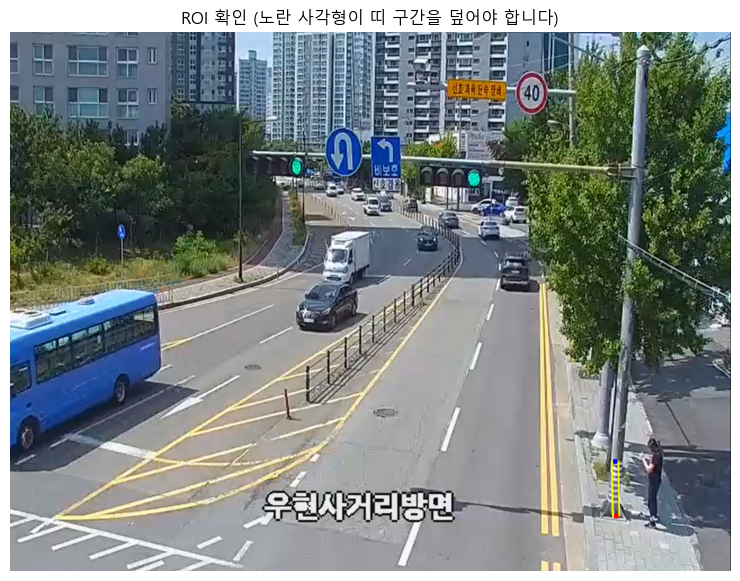

저장: C:\Project\PythonProject\PyTorch001\final_project\marker_roi.json


In [6]:
# ── 보정용 이미지: 반드시 '표식이 붙어 있는' 캡처를 쓰세요 ─────────────
# (표식 없는 원본 dry_original.png 로는 띠를 찾을 수 없습니다)
MARKER_IMAGE = r"C:\Users\Win11Pro\Desktop\flood_depth_cctv_package\flood_depth_cctv\assets\marker_reference.png"
dry = imread_kr(MARKER_IMAGE)
print("이미지 크기: 가로", dry.shape[1], "세로", dry.shape[0])

# 기둥이 어디 있는지 찾을 때 (선택) — 톱니 구간이 띠입니다
# probe_column(dry, x=1196, y0=800, y1=980)

# (A) 클릭으로 지정
# roi = pick_roi_by_click(dry, half_width_px=7)

# (B) 좌표 직접 입력 — marker_reference.png (1424x1066) 기준 실측값
roi = make_roi(p_bottom=(1197, 957),   # 기둥이 보도면과 만나는 접점
               p_top=(1195, 849),      # 최상단 흰띠의 위쪽 끝
               half_width_px=7,        # 기둥 반폭. 배경(밝은 보도)이 섞이지 않게 좁게
               img=dry)                # ← 좌표 범위 자동 검증

show(preview_roi(dry, roi), "ROI 확인 (노란 사각형이 띠 구간을 덮어야 합니다)")
save_json("marker_roi.json", roi)
print("저장:", Path("marker_roi.json").resolve())

## 4. 기둥 축 정렬(rectify) + 밝기 프로파일기울어진 기둥 ROI를 세로 직사각형으로 펴고(`rectify_band`), 가로 방향 중앙값을 취해**1차원 밝기 프로파일**을 만듭니다. 행 0 = 표식 상단, 마지막 행 = 기둥 하단입니다.

In [7]:
def fit_to_calib_size(img, roi):
    """보정에 쓴 이미지와 해상도가 다르면 맞춰 줍니다(스크린샷 vs 실제 스트림 등)."""
    sz = roi.get("image_size")
    if not sz:
        return img
    if (img.shape[1], img.shape[0]) != (sz[0], sz[1]):
        img = cv2.resize(img, (sz[0], sz[1]), interpolation=cv2.INTER_LINEAR)
    return img


def rectify_band(img, roi):
    """ROI를 세로 직사각형으로 워프. 크기는 ROI에 고정 저장된 값을 씁니다.
    반환: (band, H, W)"""
    img = fit_to_calib_size(img, roi)
    pb = np.array(roi["p_bottom"], np.float32)
    pt = np.array(roi["p_top"], np.float32)
    axis = pt - pb
    L = float(np.linalg.norm(axis))
    if L < 10:
        raise ValueError("ROI 두 점이 너무 가깝습니다.")
    u = axis / L
    n = np.array([-u[1], u[0]], np.float32)
    hw = float(roi["half_width_px"])
    H = int(roi.get("band_height") or round(L))
    W = int(roi.get("band_width") or max(6, round(hw * 2)))
    src = np.float32([pt - n * hw, pt + n * hw, pb + n * hw, pb - n * hw])
    dst = np.float32([[0, 0], [W - 1, 0], [W - 1, H - 1], [0, H - 1]])
    M = cv2.getPerspectiveTransform(src, dst)
    band = cv2.warpPerspective(img, M, (W, H), flags=cv2.INTER_CUBIC)
    return band, H, W


def band_profile(band, blur=3):
    """밴드 → 1D 밝기 프로파일(행 방향). 폐색에 강하도록 열 중앙값 사용."""
    g = cv2.cvtColor(band, cv2.COLOR_BGR2GRAY) if band.ndim == 3 else band
    g = cv2.GaussianBlur(g, (0, 0), 1.0)
    prof = np.median(g.astype(np.float32), axis=1)
    if blur and blur > 1:
        k = np.ones(blur, np.float32) / blur
        prof = np.convolve(prof, k, mode="same")
    return prof


def local_normalize(prof, win):
    """국소 min-max 정규화 → 조명/그림자 변화에 강함. 0~1 반환."""
    p = prof.reshape(-1, 1).astype(np.float32)
    win = int(max(3, win | 1))
    ker = np.ones((win, 1), np.uint8)
    pmin = cv2.erode(p, ker, borderType=cv2.BORDER_REPLICATE)
    pmax = cv2.dilate(p, ker, borderType=cv2.BORDER_REPLICATE)
    rng = (pmax - pmin).ravel()
    norm = (prof - pmin.ravel()) / np.maximum(rng, 1e-6)
    return np.clip(norm, 0, 1), rng


def px_per_cm(roi, H):
    """ROI 두 점의 실제 높이차로 대략적인 px/cm 산출(초기 추정용)."""
    span_cm = roi["top_cm"] - roi["bottom_cm"]
    return H / max(span_cm, 1e-6), span_cm

print("rectify/profile 함수 준비 완료")

rectify/profile 함수 준비 완료


밴드 크기: 400x52 px | 실제 구간: 100 cm | 초기 px/cm ≈ 4.00
흰띠 1개 ≈ 20.0 px, 주기 ≈ 40.0 px


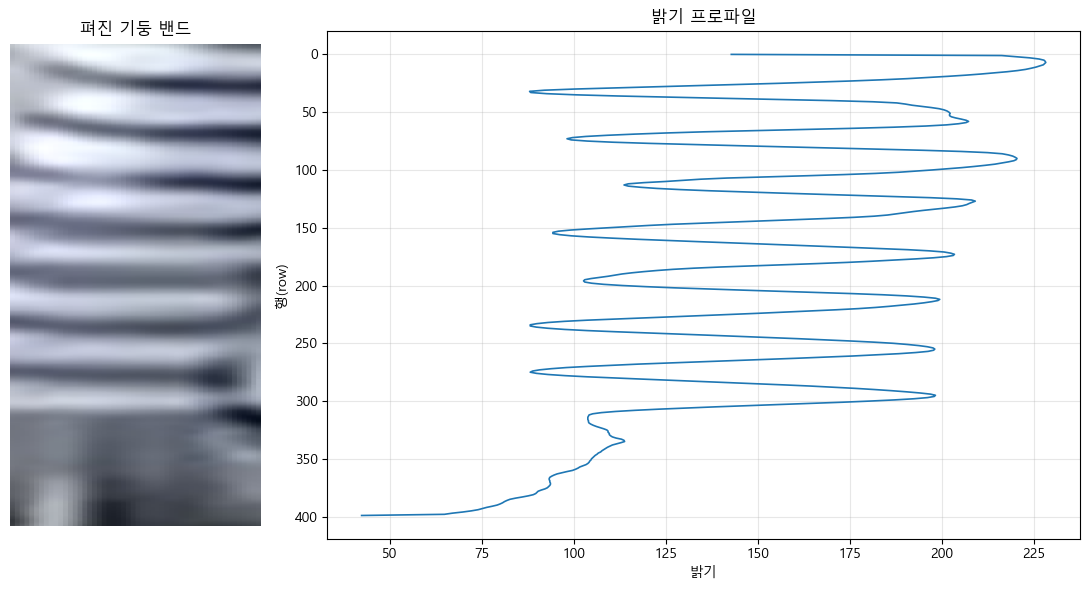

In [8]:
band, H, W = rectify_band(dry, roi)
prof = band_profile(band)
ppc, span_cm = px_per_cm(roi, H)
print(f"밴드 크기: {H}x{W} px | 실제 구간: {span_cm:.0f} cm | 초기 px/cm ≈ {ppc:.2f}")
print(f"흰띠 1개 ≈ {ppc * SPEC.stripe_cm:.1f} px, 주기 ≈ {ppc * SPEC.period_cm:.1f} px")

fig, ax = plt.subplots(1, 2, figsize=(11, 6), gridspec_kw={"width_ratios": [1, 3]})
ax[0].imshow(cv2.cvtColor(cv2.resize(band, (W * 4, H), interpolation=cv2.INTER_NEAREST), cv2.COLOR_BGR2RGB))
ax[0].set_title("펴진 기둥 밴드"); ax[0].axis("off")
ax[1].plot(prof, np.arange(H), lw=1.2)
ax[1].invert_yaxis(); ax[1].set_xlabel("밝기"); ax[1].set_ylabel("행(row)"); ax[1].grid(alpha=.3)
ax[1].set_title("밝기 프로파일")
plt.tight_layout(); plt.show()

## 5. 흰띠 검출국소 정규화한 프로파일에서 임계값을 넘는 **연속 구간(run)** 을 띠 후보로 잡고,길이·대비 조건으로 걸러냅니다. 기둥이 밝고 띠가 어두운 경우도 있어 **극성(polarity)을 자동 판단**합니다.

In [9]:
def _runs_above(mask):
    """불리언 배열에서 연속 True 구간 [(start, end_exclusive), ...]"""
    idx = np.flatnonzero(np.diff(np.concatenate(([0], mask.view(np.int8), [0]))))
    return list(zip(idx[0::2], idx[1::2]))


def detect_stripes(prof, ppc, spec=SPEC, thr=0.55, min_contrast=8.0, polarity="auto"):
    """프로파일에서 띠 검출.
    반환: dict(centers, spans, polarity, norm, contrast)
      centers : 띠 중심 행(float) 리스트 (위→아래 순)
    """
    stripe_px = max(2.0, ppc * spec.stripe_cm)
    win = int(round(ppc * spec.period_cm * 1.6)) | 1
    cands = ["bright", "dark"] if polarity == "auto" else [polarity]

    best = None
    for pol in cands:
        p = prof if pol == "bright" else (255.0 - prof)
        norm, rng = local_normalize(p, win)
        mask = (norm > thr) & (rng > min_contrast)
        runs = [(s, e) for s, e in _runs_above(mask)
                if 0.35 * stripe_px <= (e - s) <= 2.2 * stripe_px]
        if not runs:
            score = -1.0
        else:
            centers = np.array([(s + e - 1) / 2.0 for s, e in runs])
            if len(centers) >= 2:
                d = np.diff(np.sort(centers))
                # 주기 일치도: 간격이 기대 주기의 정수배에 얼마나 가까운가
                ratio = d / (ppc * spec.period_cm)
                err = np.abs(ratio - np.round(np.clip(ratio, 1, None)))
                score = len(centers) * float(np.mean(err < 0.22))
            else:
                score = 0.5
        if best is None or score > best["score"]:
            best = {"score": score, "polarity": pol, "norm": norm, "contrast": rng,
                    "runs": runs}

    runs = best["runs"]
    centers = [ (s + e - 1) / 2.0 for s, e in runs ]
    order = np.argsort(centers)
    return {
        "centers": [float(centers[i]) for i in order],
        "spans": [(int(runs[i][0]), int(runs[i][1])) for i in order],
        "polarity": best["polarity"],
        "norm": best["norm"],
        "contrast": best["contrast"],
        "score": float(best["score"]),
    }

print("띠 검출 함수 준비 완료")

띠 검출 함수 준비 완료


극성: bright | 검출된 띠 개수: 8 | 점수: 8.00
띠 중심 행: [12.5, 52.5, 92.5, 132.0, 173.5, 214.5, 254.5, 294.0]


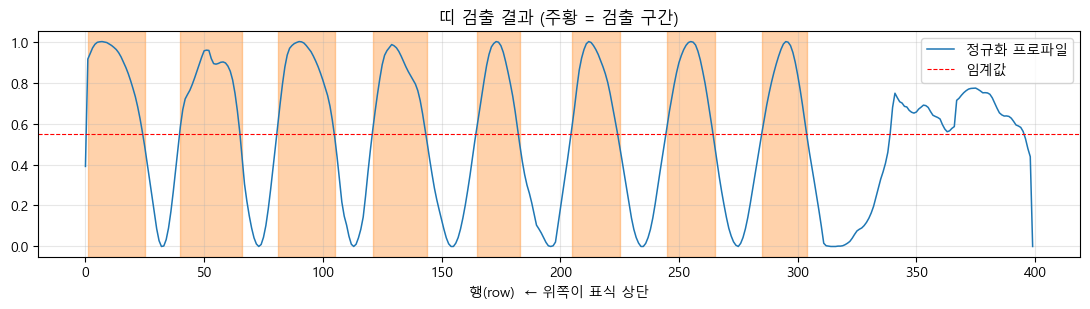

In [10]:
det = detect_stripes(prof, ppc, SPEC)
print(f"극성: {det['polarity']} | 검출된 띠 개수: {len(det['centers'])} | 점수: {det['score']:.2f}")
print("띠 중심 행:", [round(c, 1) for c in det["centers"]])

plt.figure(figsize=(11, 3.2))
plt.plot(det["norm"], lw=1.1, label="정규화 프로파일")
for s, e in det["spans"]:
    plt.axvspan(s, e, color="tab:orange", alpha=.35)
plt.axhline(0.55, color="r", ls="--", lw=.8, label="임계값")
plt.xlabel("행(row)  ← 위쪽이 표식 상단"); plt.legend(); plt.grid(alpha=.3)
plt.title("띠 검출 결과 (주황 = 검출 구간)"); plt.tight_layout(); plt.show()

# 검출 개수가 실제 띠 개수와 다르면 thr(0.45~0.7), half_width_px, n_stripes를 조정하세요.

## 6. 보정(calibrate) — 픽셀 행 ↔ 실제 cm검출된 띠 중심을 **기대 높이(cm)** 에 대응시켜 `height_cm = f(row)` 를 회귀합니다.원근 때문에 완전한 선형이 아니므로 띠가 5개 이상이면 2차 다항식을 씁니다.

In [11]:
def initial_row_to_cm(roi, H):
    """ROI 두 점만으로 만든 1차 초기 모델."""
    top_cm, bot_cm = roi["top_cm"], roi["bottom_cm"]
    return lambda r: top_cm + (bot_cm - top_cm) * (np.asarray(r, np.float64) / max(H - 1, 1))


def _match_pairs(centers, f0, spec, tol_ratio):
    """검출 행 → (행, 기대 cm, 띠번호) 매칭. 이미 쓰인 띠 번호는 재사용하지 않습니다."""
    expected = np.array([spec.stripe_center_cm(i) for i in range(1, spec.n_stripes + 1)])
    tol = spec.period_cm * tol_ratio
    pairs, used = [], set()
    for c in centers:
        cm_guess = float(f0(c))
        k = int(np.argmin(np.abs(expected - cm_guess)))
        if abs(expected[k] - cm_guess) <= tol and k not in used:
            used.add(k)
            pairs.append((float(c), float(expected[k]), k + 1))
    return pairs


def _fit_pairs(pairs, H):
    rows = np.array([p[0] for p in pairs], np.float64)
    cms = np.array([p[1] for p in pairs], np.float64)
    deg = 2 if len(pairs) >= 5 else 1
    coef = np.polyfit(rows, cms, deg)
    # 2차 회귀가 구간 내에서 단조 감소하지 않으면 1차로 폴백
    if deg == 2 and np.any(np.diff(np.polyval(coef, np.arange(H))) > 0):
        coef, deg = np.polyfit(rows, cms, 1), 1
    rmse = float(np.sqrt(np.mean((np.polyval(coef, rows) - cms) ** 2)))
    return coef, deg, rmse


def calibrate(prof, roi, H, spec=SPEC, thr=0.55, tol_ratio=0.45, polarity="auto", verbose=True):
    """띠 검출 → 기대 높이 매칭 → 다항 회귀. 반환: calib dict

    극성(밝은 띠 / 어두운 띠)은 '매칭된 띠 개수 → RMSE' 순으로 자동 선택합니다.
    간격(gap)을 띠로 오인하면 정확히 반주기(5cm) 어긋나므로 이 단계에서 걸러집니다.
    """
    ppc, _ = px_per_cm(roi, H)
    f0 = initial_row_to_cm(roi, H)
    cands = ["bright", "dark"] if polarity == "auto" else [polarity]

    best = None
    for pol in cands:
        det = detect_stripes(prof, ppc, spec, thr=thr, polarity=pol)
        if len(det["centers"]) < 3:
            continue
        pairs = _match_pairs(det["centers"], f0, spec, tol_ratio)
        if len(pairs) < 3:
            continue
        coef, deg, rmse = _fit_pairs(pairs, H)
        cand = {"pol": pol, "pairs": pairs, "coef": coef, "deg": deg, "rmse": rmse}
        if best is None or (len(pairs), -rmse) > (len(best["pairs"]), -best["rmse"]):
            best = cand
        if verbose:
            print(f"  [극성 {pol:>6}] 검출 {len(det['centers'])}개 / 매칭 {len(pairs)}개 / RMSE {rmse:.2f} cm")

    if best is None:
        raise RuntimeError("띠를 3개 이상 매칭하지 못했습니다. ROI 두 점 위치, n_stripes, thr을 확인하세요.")

    pairs, coef, deg, rmse = best["pairs"], best["coef"], best["deg"], best["rmse"]
    calib = {
        "coef": [float(c) for c in coef], "degree": int(deg), "rmse_cm": rmse,
        "band_height": int(H), "polarity": best["pol"], "thr": float(thr),
        "matched": [{"row": float(r), "cm": float(c), "stripe_index": int(i)} for r, c, i in pairs],
        "roi": roi, "spec": asdict(spec),
    }
    if verbose:
        print(f"→ 선택 극성 {best['pol']} | 매칭 띠 {len(pairs)}/{spec.n_stripes}개 | 차수 {deg} | RMSE {rmse:.2f} cm")
        for r, c, i in pairs:
            print(f"  띠 {i:>2} : row {r:7.1f} → {c:5.1f} cm")
        if rmse > 1.5:
            print("  ⚠ RMSE가 큽니다. ROI 상/하단 점 위치를 다시 확인해 주세요.")
    return calib


def row_to_cm(calib, row):
    return float(np.polyval(np.array(calib["coef"]), float(row)))


def cm_to_row(calib, cm):
    """cm → row 역변환 (구간 내 이분 탐색)."""
    H = calib["band_height"]
    rr = np.arange(H, dtype=np.float64)
    vals = np.polyval(np.array(calib["coef"]), rr)   # 단조 감소
    return float(np.interp(cm, vals[::-1], rr[::-1]))

print("보정 함수 준비 완료")

보정 함수 준비 완료


  [극성 bright] 검출 8개 / 매칭 8개 / RMSE 0.13 cm
  [극성   dark] 검출 8개 / 매칭 7개 / RMSE 0.08 cm
→ 선택 극성 bright | 매칭 띠 8/8개 | 차수 2 | RMSE 0.13 cm
  띠  8 : row    12.5 → 111.5 cm
  띠  7 : row    52.5 → 101.5 cm
  띠  6 : row    92.5 →  91.5 cm
  띠  5 : row   132.0 →  81.5 cm
  띠  4 : row   173.5 →  71.5 cm
  띠  3 : row   214.5 →  61.5 cm
  띠  2 : row   254.5 →  51.5 cm
  띠  1 : row   294.0 →  41.5 cm

저장: C:\Project\PythonProject\PyTorch001\final_project\marker_calibration.json


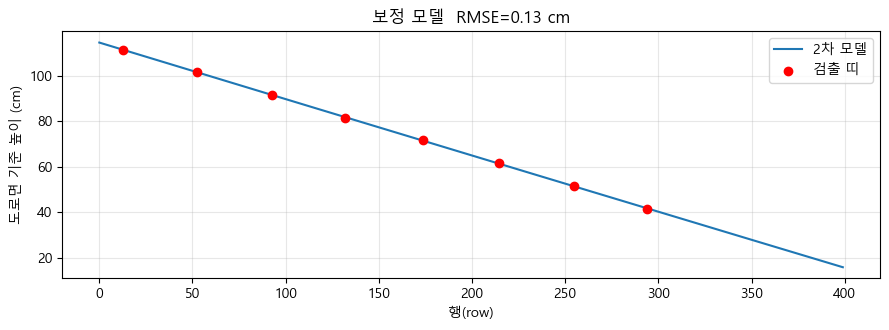

In [12]:
calib = calibrate(prof, roi, H, SPEC, thr=0.55)
calib["dry_profile"] = [float(v) for v in prof]      # 침수 판정 시 기준 프로파일로 사용
save_json("marker_calibration.json", calib)
print("\n저장:", Path("marker_calibration.json").resolve())

rr = np.arange(H)
plt.figure(figsize=(9, 3.4))
plt.plot(rr, np.polyval(np.array(calib["coef"]), rr), lw=1.5, label=f"{calib['degree']}차 모델")
m = calib["matched"]
plt.scatter([d["row"] for d in m], [d["cm"] for d in m], c="r", zorder=3, label="검출 띠")
plt.xlabel("행(row)"); plt.ylabel("도로면 기준 높이 (cm)"); plt.grid(alpha=.3); plt.legend()
plt.title(f"보정 모델  RMSE={calib['rmse_cm']:.2f} cm"); plt.tight_layout(); plt.show()

## 7. 측정(measure) — 가장 낮게 보이는 띠 찾기| 상황 | 판정 | 정밀도 ||---|---|---|| 최하단 가시 띠가 **일부만** 보임 | 수면은 그 띠 **내부** → 검출된 아래쪽 끝을 수면선으로 | ±1~2 cm || 띠 하나가 **통째로** 잠김 | 수면은 `[잠긴 띠 상단, 보이는 띠 하단]` 구간 → 기준 영상 차분으로 정밀화 | ±1~5 cm || 1번 띠까지 **다** 보임 | 수면은 삼각부 구간(14~39 cm) 이하 → 차분으로 정밀화 | ±3 cm || 띠가 **하나도** 안 보임 | 완전 침수 또는 가림 → 최상단 띠 높이 이상으로 보고 | 하한값만 |'보인다'의 판정은 검출 임계값만으로 하지 않고, **마른 날 대비 국소 대비 비율**(`vis_ratio`, 기본 0.35)로한 번 더 거릅니다. 물에 잠긴 띠는 대비가 급감하기 때문입니다.

In [13]:
def match_visible_stripes(det, calib, spec=SPEC, tol_ratio=0.45):
    """검출된 띠 → 띠 번호 매칭. 반환: {띠번호: {"row": 중심행, "span": (시작행, 끝행)}}"""
    tol = spec.period_cm * tol_ratio
    expected = {i: spec.stripe_center_cm(i) for i in range(1, spec.n_stripes + 1)}
    out = {}
    for c, (s, e) in zip(det["centers"], det["spans"]):
        cm = row_to_cm(calib, c)
        k, best = None, 1e9
        for i, ex in expected.items():
            if abs(ex - cm) < best:
                k, best = i, abs(ex - cm)
        if best <= tol and k not in out:
            out[k] = {"row": float(c), "span": (int(s), int(e))}
    return dict(sorted(out.items()))


def stripe_visibility(visible, prof_now, calib, spec, ppc, vis_ratio=0.35):
    """마른 날 대비 국소 대비가 충분히 남은 띠만 '보인다'로 인정.

    잠긴 띠는 감쇠·산란으로 대비가 급감합니다. 검출 임계값만으로는 희미한 잔상을
    띠로 오인할 수 있어 기준 영상과의 대비 비율로 한 번 더 거릅니다.
    """
    dry = np.array(calib.get("dry_profile", []), np.float32)
    if dry.size != prof_now.size:
        return visible, {}
    win = int(round(ppc * spec.period_cm * 1.6)) | 1
    _, rng_now = local_normalize(prof_now.astype(np.float32), win)
    _, rng_dry = local_normalize(dry, win)
    out, ratios = {}, {}
    for i, v in visible.items():
        r = int(np.clip(round(v["row"]), 0, len(rng_now) - 1))
        ratio = float(rng_now[r] / max(rng_dry[r], 1e-6))
        ratios[i] = round(ratio, 3)
        if ratio >= vis_ratio:
            out[i] = v
    return dict(sorted(out.items())), ratios


def refine_waterline(prof_now, calib, row_lo, row_hi, diff_thr=0.30, min_run=3):
    """[row_lo, row_hi] 구간에서 기준 프로파일과 달라지기 시작하는 최상단 행 탐색."""
    dry = np.array(calib.get("dry_profile", []), np.float32)
    if dry.size != prof_now.size:
        return None
    win = int(max(5, calib["band_height"] * 0.06)) | 1
    a, _ = local_normalize(dry, win)
    b, _ = local_normalize(prof_now.astype(np.float32), win)
    d = np.abs(a - b)
    lo, hi = int(max(0, row_lo)), int(min(len(d), row_hi + 1))
    if hi - lo < min_run:
        return None
    for s, e in _runs_above(d[lo:hi] > diff_thr):
        if e - s >= min_run:
            return float(lo + s)          # 위에서부터 처음 달라지는 지점 = 수면선
    return None


def measure_frame(img, calib, spec=SPEC, thr=None, refine=True,
                  vis_ratio=0.35, partial_margin_cm=1.5):
    """한 프레임 → 침수심 측정 결과 dict

    판정 순서
      1) 최하단 가시 띠가 '일부만' 보이면 → 수면은 그 띠 내부 (가장 정확, ±1~2cm)
      2) 띠가 통째로 잠겼으면 → 수면은 [잠긴 띠 상단, 보이는 띠 하단] 구간 (±5cm)
      3) 1번 띠까지 다 보이면 → 수면은 삼각부 구간(14~39cm) 이하
    """
    roi_ = calib["roi"]
    band, H, W = rectify_band(img, roi_)          # 해상도 정합 + 밴드 크기 고정은 내부 처리
    prof_now = band_profile(band)
    ppc, _ = px_per_cm(roi_, H)
    det = detect_stripes(prof_now, ppc, spec,
                         thr=calib["thr"] if thr is None else thr,
                         polarity=calib["polarity"])
    visible = match_visible_stripes(det, calib, spec)
    visible, ratios = stripe_visibility(visible, prof_now, calib, spec, ppc, vis_ratio)

    res = {"visible_stripes": sorted(visible.keys()), "n_visible": len(visible),
           "band": band, "profile": prof_now, "det": det, "contrast_ratio": ratios,
           "depth_cm": None, "depth_lo_cm": None, "depth_hi_cm": None,
           "waterline_row": None, "method": None, "status": "", "level": None}

    # ── 케이스 0: 띠가 하나도 안 보임 → 완전 침수 또는 가림 ──────────────
    if not visible:
        res["status"] = "NO_STRIPE"
        res["depth_lo_cm"] = float(spec.stripe_bounds_cm(spec.n_stripes)[1])
        res["depth_cm"] = float(spec.stripe_bounds_cm(spec.n_stripes)[1])
        res["method"] = "all_submerged_or_occluded"
        res["level"] = classify_level(res["depth_cm"])
        return res

    i_min = min(visible.keys())
    s, e = visible[i_min]["span"]
    cm_bottom_seen = row_to_cm(calib, e - 1)          # 보이는 띠의 아래쪽 끝 높이
    lo_exp, hi_exp = spec.stripe_bounds_cm(i_min)

    if cm_bottom_seen > lo_exp + partial_margin_cm:
        # ── 케이스 1: 띠가 일부만 보임 → 수면이 그 띠 내부 ────────────────
        res.update(status="OK", method="partial_stripe",
                   depth_cm=float(np.clip(cm_bottom_seen, lo_exp, hi_exp)),
                   depth_lo_cm=float(lo_exp), depth_hi_cm=float(hi_exp),
                   waterline_row=float(e - 1))

    elif i_min > 1:
        # ── 케이스 2: 아래 띠가 통째로 잠김 ──────────────────────────────
        lo = float(spec.stripe_bounds_cm(i_min - 1)[1])
        hi = float(lo_exp)
        res.update(status="OK", method="stripe_count",
                   depth_cm=(lo + hi) / 2.0, depth_lo_cm=lo, depth_hi_cm=hi)
        if refine:
            wl = refine_waterline(prof_now, calib, cm_to_row(calib, hi), cm_to_row(calib, lo))
            if wl is not None:
                cm = row_to_cm(calib, wl)
                if lo - 1.0 <= cm <= hi + 1.0:
                    res.update(depth_cm=float(np.clip(cm, lo, hi)), waterline_row=float(wl),
                               method="stripe_count+edge_refine")
    else:
        # ── 케이스 3: 1번 띠까지 다 보임 → 수면은 삼각부 이하 ─────────────
        lo, hi = float(roi_["bottom_cm"]), float(lo_exp)      # 보도면(14) ~ 첫 띠 하단(39)
        res.update(status="BELOW_MARKER", method="stripe_count",
                   depth_cm=(lo + hi) / 2.0, depth_lo_cm=lo, depth_hi_cm=hi)
        wl = refine_waterline(prof_now, calib, cm_to_row(calib, hi), H - 1) if refine else None
        if wl is not None:
            res.update(depth_cm=float(np.clip(row_to_cm(calib, wl), lo, hi)),
                       waterline_row=float(wl), method="triangle_edge_refine")
        else:
            # 삼각부에도 변화가 없음 → 수면이 보도면보다 낮음(도로만 침수)
            res.update(status="BELOW_SIDEWALK", method="no_change",
                       depth_cm=float(roi_["bottom_cm"]) / 2.0,
                       depth_lo_cm=0.0, depth_hi_cm=float(roi_["bottom_cm"]))

    if res["waterline_row"] is None and res["depth_cm"] is not None:
        try:
            res["waterline_row"] = cm_to_row(calib, res["depth_cm"])
        except Exception:
            pass
    res["level"] = classify_level(res["depth_cm"])
    return res


print("측정 함수 준비 완료")

측정 함수 준비 완료


## 8. 시각화

In [14]:
def _put_text(img, text, org, color=(255, 255, 255), size=22):
    """한글 지원 텍스트(가능하면 PIL, 아니면 cv2 영문 폴백)."""
    try:
        from PIL import Image, ImageDraw, ImageFont
        for fp in [r"C:\Windows\Fonts\malgun.ttf", r"C:\Windows\Fonts\NanumGothic.ttf",
                   "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"]:
            if Path(fp).exists():
                pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                d = ImageDraw.Draw(pil)
                d.text(org, text, font=ImageFont.truetype(fp, size), fill=color[::-1])
                img[:] = cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)
                return img
    except Exception:
        pass
    cv2.putText(img, text, (org[0], org[1] + size), cv2.FONT_HERSHEY_SIMPLEX,
                size / 30.0, color, 2, cv2.LINE_AA)
    return img


def band_row_to_image_pt(roi, calib, row, offset_ratio=0.0):
    """밴드 행 → 원본 이미지 좌표."""
    pb = np.array(roi["p_bottom"], np.float64)
    pt = np.array(roi["p_top"], np.float64)
    H = calib["band_height"]
    t = float(row) / max(H - 1, 1)              # 0=상단, 1=하단
    p = pt + (pb - pt) * t
    axis = pt - pb
    n = np.array([-axis[1], axis[0]]) / (np.linalg.norm(axis) + 1e-9) * roi["half_width_px"]
    return p + n * offset_ratio


def annotate(img, res, calib, spec=SPEC, tag=""):
    roi_ = calib["roi"]
    vis = preview_roi(img, roi_, spec)

    # 보이는 띠 표시
    for i in res["visible_stripes"]:
        r = cm_to_row(calib, spec.stripe_center_cm(i))
        a = band_row_to_image_pt(roi_, calib, r, -1.6)
        b = band_row_to_image_pt(roi_, calib, r, 1.6)
        cv2.line(vis, tuple(np.int32(a)), tuple(np.int32(b)), (0, 255, 0), 2, cv2.LINE_AA)

    # 수면선
    if res["waterline_row"] is not None:
        a = band_row_to_image_pt(roi_, calib, res["waterline_row"], -4.0)
        b = band_row_to_image_pt(roi_, calib, res["waterline_row"], 4.0)
        cv2.line(vis, tuple(np.int32(a)), tuple(np.int32(b)), (255, 80, 0), 3, cv2.LINE_AA)

    lv = res["level"] if res["level"] is not None else 0
    color = LEVEL_COLORS_BGR[lv]
    h, w = vis.shape[:2]
    pad = np.zeros((110, w, 3), np.uint8)
    cv2.rectangle(pad, (0, 0), (w, 110), (30, 30, 30), -1)
    cv2.rectangle(pad, (0, 0), (14, 110), color, -1)
    rng = "" if res["depth_hi_cm"] is None else f"  (범위 {res['depth_lo_cm']:.0f}~{res['depth_hi_cm']:.0f} cm)"
    _put_text(pad, f"도로 침수심 {res['depth_cm']:.1f} cm{rng}", (26, 8), (255, 255, 255), 30)
    _put_text(pad, f"{LEVEL_NAMES[lv]} | 보이는 띠 {res['n_visible']}개 | {res['method']} {tag}",
              (26, 52), (200, 220, 240), 22)
    _put_text(pad, f"보도면 위 수위 {max(0.0, res['depth_cm'] - spec.curb_height_cm):.1f} cm | 상태 {res['status']}",
              (26, 80), (170, 190, 210), 20)
    return np.vstack([pad, vis])

print("시각화 함수 준비 완료")

시각화 함수 준비 완료


## 9. 단일 이미지 측정 실행

In [15]:
FLOOD_IMAGE = r"C:\Project\PythonProject\PyTorch001\data\flood_sample.png"   # 침수 프레임

calib = load_json("marker_calibration.json")
SPEC = MarkerSpec(**calib["spec"])

frame = imread_kr(FLOOD_IMAGE)
res = measure_frame(frame, calib, SPEC)

print(f"보이는 띠      : {res['visible_stripes']}")
print(f"상태           : {res['status']} / {res['method']}")
print(f"도로 침수심    : {res['depth_cm']:.1f} cm"
      + ("" if res["depth_hi_cm"] is None else f"  (범위 {res['depth_lo_cm']:.0f}~{res['depth_hi_cm']:.0f} cm)"))
print(f"침수 등급      : {LEVEL_NAMES[res['level']]}")

out = annotate(frame, res, calib, SPEC)
show(out, "측정 결과")
imwrite_kr("result_single.png", out)

FileNotFoundError: 파일이 없습니다: C:\Project\PythonProject\PyTorch001\data\flood_sample.png

## 10. 동영상 / 이미지 폴더 일괄 처리 + CSV

In [ ]:
import csv
from collections import deque


def measure_video(video_path, calib, spec=SPEC, out_video=None, out_csv="flood_depth_log.csv",
                  frame_step=5, smooth_n=7, show_progress=True):
    """동영상 전체를 처리하고 CSV/결과영상 저장. 중앙값 평활로 프레임 튐 억제."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"영상을 열 수 없습니다: {video_path}")
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)

    writer, hist, rows, idx = None, deque(maxlen=smooth_n), [], 0
    try:
        while True:
            ok, frame = cap.read()
            if not ok:
                break
            if idx % frame_step != 0:
                idx += 1
                continue
            try:
                r = measure_frame(frame, calib, spec)
            except Exception as e:
                idx += 1
                continue
            if r["depth_cm"] is not None:
                hist.append(r["depth_cm"])
                r["depth_cm"] = float(np.median(hist))
                r["level"] = classify_level(r["depth_cm"])
            vis = annotate(frame, r, calib, spec, tag=f"| frame {idx}")
            if out_video:
                if writer is None:
                    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
                    writer = cv2.VideoWriter(str(out_video), fourcc, fps / frame_step,
                                             (vis.shape[1], vis.shape[0]))
                writer.write(vis)
            rows.append([idx, round(idx / fps, 2), r["n_visible"],
                         ";".join(map(str, r["visible_stripes"])),
                         "" if r["depth_cm"] is None else round(r["depth_cm"], 1),
                         r["level"], r["status"], r["method"]])
            if show_progress and len(rows) % 20 == 0:
                print(f"  {idx}/{total} 프레임 처리 중... 최근 침수심 {rows[-1][4]} cm")
            idx += 1
    finally:
        cap.release()
        if writer is not None:
            writer.release()

    with open(out_csv, "w", newline="", encoding="utf-8-sig") as f:
        w = csv.writer(f)
        w.writerow(["frame", "time_s", "n_visible", "visible_stripes",
                    "road_depth_cm", "level", "status", "method"])
        w.writerows(rows)
    print(f"완료: {len(rows)}개 프레임 → {Path(out_csv).resolve()}")
    return rows


# 실행 예시
# rows = measure_video(r"C:\Project\PythonProject\PyTorch001\data\flood.mp4",
#                      calib, SPEC, out_video="flood_result.mp4", frame_step=5)

In [ ]:
def plot_depth_series(csv_path="flood_depth_log.csv"):
    import csv as _csv
    ts, ds = [], []
    with open(csv_path, encoding="utf-8-sig") as f:
        for row in _csv.DictReader(f):
            if row["road_depth_cm"]:
                ts.append(float(row["time_s"])); ds.append(float(row["road_depth_cm"]))
    plt.figure(figsize=(11, 3.6))
    plt.plot(ts, ds, lw=1.5)
    for t, name in zip(LEVEL_THRESHOLDS_CM, LEVEL_NAMES[1:]):
        plt.axhline(t, ls="--", lw=.8, alpha=.6)
        plt.text(ts[0] if ts else 0, t + .5, name, fontsize=8)
    plt.xlabel("시간 (s)"); plt.ylabel("도로 침수심 (cm)"); plt.grid(alpha=.3)
    plt.title("시간에 따른 침수심"); plt.tight_layout(); plt.show()

# plot_depth_series()

## 11. 합성 검증 — 정답을 알고 있는 가짜 침수 영상으로 정확도 확인실제 침수 영상이 없어도, 마른 날 영상의 아래쪽을 물처럼 가려서**설정한 침수심 vs 측정된 침수심**을 비교할 수 있습니다.

In [ ]:
def synth_flood(dry_img, calib, target_depth_cm, spec=SPEC, tint=0.90):
    """지정한 침수심만큼 아래쪽을 물처럼 변형한 합성 이미지."""
    roi_ = calib["roi"]
    row = cm_to_row(calib, target_depth_cm)
    p = band_row_to_image_pt(roi_, calib, row)
    y = float(p[1])
    out = dry_img.astype(np.float32)
    yy = np.arange(out.shape[0])[:, None, None]
    alpha = np.clip((yy - y + 3) / 10.0, 0, 1)
    blurred = cv2.GaussianBlur(out, (0, 0), 9.0)
    flat = np.zeros_like(out) + np.array([118.0, 104.0, 88.0], np.float32)   # 탁한 흙탕물 색
    rng = np.random.default_rng(0)
    ripple = cv2.GaussianBlur(rng.normal(0, 8, out.shape[:2]).astype(np.float32), (0, 0), 3.0)[..., None]
    water = 0.70 * flat + 0.30 * blurred + ripple
    water[..., 0] = np.clip(water[..., 0] * 1.10 + 14, 0, 255)
    water[..., 1] = np.clip(water[..., 1] * 0.96 + 4, 0, 255)
    water[..., 2] = np.clip(water[..., 2] * 0.84, 0, 255)
    out = out * (1 - tint * alpha) + water * (tint * alpha)
    out = np.clip(out, 0, 255).astype(np.uint8)
    cv2.line(out, (0, int(y)), (out.shape[1] - 1, int(y)), (225, 228, 230), 2)
    return out


def run_accuracy_test(dry_img, calib, spec=SPEC, targets=(20, 32, 45, 58, 70)):
    print(f"{'정답(cm)':>9}{'측정(cm)':>10}{'오차':>8}{'보이는 띠':>10}   방법")
    print("-" * 58)
    errs = []
    for t in targets:
        syn = synth_flood(dry_img, calib, t, spec)
        r = measure_frame(syn, calib, spec)
        if r["depth_cm"] is None:
            print(f"{t:>9}{'실패':>10}"); continue
        e = r["depth_cm"] - t
        errs.append(abs(e))
        print(f"{t:>9}{r['depth_cm']:>10.1f}{e:>+8.1f}{r['n_visible']:>10}   {r['method']}")
    if errs:
        print(f"\n평균 절대 오차: {np.mean(errs):.2f} cm | 최대 오차: {np.max(errs):.2f} cm")
    return errs


# errs = run_accuracy_test(dry, calib, SPEC)
# show(annotate(synth_flood(dry, calib, 45), measure_frame(synth_flood(dry, calib, 45), calib, SPEC), calib, SPEC), "합성 45cm 검증")

## 12. 튜닝 가이드 (검출이 잘 안 될 때)| 증상 | 원인 | 조치 ||---|---|---|| 띠가 하나도 안 잡힘 | ROI가 기둥을 벗어남 | `preview_roi` 로 사각형이 기둥을 덮는지 확인, `half_width_px` 조정 || 띠가 너무 많이 잡힘 | 임계값이 낮음 / 배경 잡음 | `thr` 을 0.55 → 0.65 로 상향, `half_width_px` 축소 || 띠가 일부만 잡힘 | 그림자·역광 | `thr` 을 0.45 로 하향, `min_contrast` 를 5 로 하향 || RMSE > 2 cm | ROI 두 점의 실제 높이가 틀림 | `p_bottom` 은 보도면 접점, `p_top` 은 **최상단 띠의 위쪽 끝** 인지 재확인 || 야간에 성능 저하 | 조명 부족 | 재귀반사 테이프 사용, 야간용 `thr` 별도 프로파일 유지 || ROI 사각형이 화면에 안 보임 | 좌표가 이미지 밖 | `make_roi(..., img=dry)` 로 실행하면 즉시 오류로 잡힙니다 || 띠가 5px 이하로 얇음 | CCTV 원거리 촬영 | `target_px_per_cm`(기본 4.0)을 올려 밴드를 더 업샘플링 || 보정 이미지에 띠가 없음 | 표식 미부착 원본 사용 | 표식 부착 캡처로 교체 || 카메라가 흔들림 | PTZ/바람 | ORB 호모그래피 정합을 앞단에 추가(기존 `flood_depth_cctv.py` 의 `estimate_homography` 재사용) |**측정 해상도**: 띠 간격이 10 cm이므로 띠 개수만으로는 **±5 cm**, 경계 정밀화가 걸리면 **±1~2 cm** 수준입니다.더 조밀한 측정이 필요하면 `stripe_cm=3, gap_cm=3` 처럼 표식을 촘촘하게 제작하시면 됩니다.